In [1]:
%pip install tensorflow matplotlib numpy scikit-learn ultralytics

  Using cached protobuf-7.35.0-cp310-abi3-win_amd64.whl.metadata (595 bytes)
   ---------------------------------------- 0.0/350.8 MB ? eta -:--:--
   ---------------------------------------- 0.8/350.8 MB 4.8 MB/s eta 0:01:13
   ---------------------------------------- 1.6/350.8 MB 4.2 MB/s eta 0:01:24
   ---------------------------------------- 2.9/350.8 MB 4.7 MB/s eta 0:01:15
   ---------------------------------------- 4.2/350.8 MB 5.0 MB/s eta 0:01:09
    --------------------------------------- 5.8/350.8 MB 5.7 MB/s eta 0:01:01
    --------------------------------------- 7.3/350.8 MB 6.1 MB/s eta 0:00:57
    --------------------------------------- 8.4/350.8 MB 5.7 MB/s eta 0:01:00
   - -------------------------------------- 10.2/350.8 MB 6.1 MB/s eta 0:00:56
   - -------------------------------------- 13.1/350.8 MB 7.0 MB/s eta 0:00:49
   - -------------------------------------- 15.2/350.8 MB 7.2 MB/s eta 0:00:47
   - -------------------------------------- 17.0/350.8 MB 7.3 MB/s et


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import sys
try:
    sys.stdout.reconfigure(encoding='utf-8')
except Exception:
    pass

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

print('TensorFlow :', tf.__version__)
print('Keras      :', keras.__version__)
print('NumPy      :', np.__version__)
print('Todo OK. (La CPU es suficiente para la clase de hoy.)')

TensorFlow : 2.21.0
Keras      : 3.14.1
NumPy      : 2.2.6
Todo OK. (La CPU es suficiente para la clase de hoy.)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 12s 1us/step
Imagenes de entrenamiento: (60000, 28, 28)
Etiquetas de entrenamiento: (60000,)
Imagenes de test: (10000, 28, 28)
Primeras 10 etiquetas: [5 0 4 1 9 2 1 3 1 4]


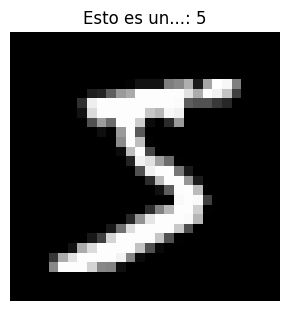

In [5]:
# Cargamos el dataset de MNIST
# keras.datasets.mnist.load_data() devuelve dos tuplas: la primera contiene los datos de entrenamiento (X_train, y_train)
# y la segunda contiene los datos de prueba (X_test, y_test).

(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

print('Imagenes de entrenamiento:', X_train.shape)
print('Etiquetas de entrenamiento:', y_train.shape)
print('Imagenes de test:', X_test.shape)
print('Primeras 10 etiquetas:', y_train[:10])

plt.figure(figsize=(3.5, 3.5))
plt.imshow(X_train[0], cmap='gray')
plt.title(f'Esto es un...: {str(y_train[0])}')
plt.axis('off')
plt.show()
 

In [6]:
print(X_train[0][4:16, 6:20])
print()
print("Cada pixel tiene un valor entre 0 y 255, donde 0 representa el color negro y 255 representa el color blanco. Los valores intermedios representan diferentes tonos de gris.")

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   3  18  18  18 126 136 175  26]
 [  0   0  30  36  94 154 170 253 253 253 253 253 225 172]
 [  0  49 238 253 253 253 253 253 253 253 253 251  93  82]
 [  0  18 219 253 253 253 253 253 198 182 247 241   0   0]
 [  0   0  80 156 107 253 253 205  11   0  43 154   0   0]
 [  0   0   0  14   1 154 253  90   0   0   0   0   0   0]
 [  0   0   0   0   0 139 253 190   2   0   0   0   0   0]
 [  0   0   0   0   0  11 190 253  70   0   0   0   0   0]
 [  0   0   0   0   0   0  35 241 225 160 108   1   0   0]
 [  0   0   0   0   0   0   0  81 240 253 253 119  25   0]
 [  0   0   0   0   0   0   0   0  45 186 253 253 150  27]]

Cada pixel tiene un valor entre 0 y 255, donde 0 representa el color negro y 255 representa el color blanco. Los valores intermedios representan diferentes tonos de gris.


In [7]:
# normalizamos los datos
X_train = X_train /255.0
X_test = X_test /255.0
print('Listo. Ahora los datos están normalizados.', X_train.min(), 'a', X_train.max())

Listo. Ahora los datos están normalizados. 0.0 a 1.0


In [8]:
modelo = keras.Sequential([

    keras.layers.Input(shape=(28, 28)), # ENTRADA: Imagenes de 28x28 pixeles
    keras.layers.Flatten(), # APLANAR, convierte la matriz de 28x28 en una fila de 784 elementos numeros
                            # (las capas DENSE necesitan trabajar con vectores)

    keras.layers.Dense(128, activation='relu'),  # CAPA OCULTA "densa": 128 neuronas conectadas al 784 del vector.
                                                 # DENSE = Cada neurona se conecta a TODAS las entradas.
                                                 # activacion relu es la "chispa" no lineal que permite aprender formas complejas
                                                 # sin ella la red solo sabría hacer rectas.

    keras.layers.Dense(10, activation='softmax') # CAPA DE SALIDA: 10 neuronas (una por digito  0-9).
                                                 # softmax convierte las 10 salidas en probabilidades que suman 1.
])


modelo.compile(
    optimizer='adam', # Adam # es un algoritmo de optimización que ajusta los pesos de la red para minimizar la función de pérdida.
    loss='sparse_categorical_crossentropy', # Función de pérdida para clasificación multi-clase
    metrics=['accuracy'] # Métrica para evaluar el rendimiento
)
modelo.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# fit es el método que se encarga de entrenar el modelo. Toma los datos de entrenamiento (X_train, y_train) y los utiliza para ajustar los pesos de la red neuronal.
# Entrenamos el modelo con los datos de entrenamiento, durante 5 épocas, y reservamos el 10% de los datos para validación.
historia = modelo.fit(X_train, y_train, epochs=5, validation_split=0.1)  

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9202 - loss: 0.2788 - val_accuracy: 0.9633 - val_loss: 0.1239
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9637 - loss: 0.1222 - val_accuracy: 0.9732 - val_loss: 0.0918
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9749 - loss: 0.0842 - val_accuracy: 0.9775 - val_loss: 0.0788
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9810 - loss: 0.0616 - val_accuracy: 0.9773 - val_loss: 0.0796
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9850 - loss: 0.0485 - val_accuracy: 0.9788 - val_loss: 0.0742


In [10]:
# evaluate es el método que se encarga de evaluar el rendimiento del modelo en un conjunto de datos de prueba (X_test, y_test).
# Devuelve la pérdida y la precisión.
# verbose=0 es para que no imprima el progreso de la evaluación.

test_acc = modelo.evaluate(X_test, y_test, verbose=0)[1]
print('Accuracy en test:', test_acc * 100, '%')
print('Es decir: acierta', round(test_acc*100), 'de cada 100 digitos que nunca habia visto')

Accuracy en test: 97.63000011444092 %
Es decir: acierta 98 de cada 100 digitos que nunca habia visto


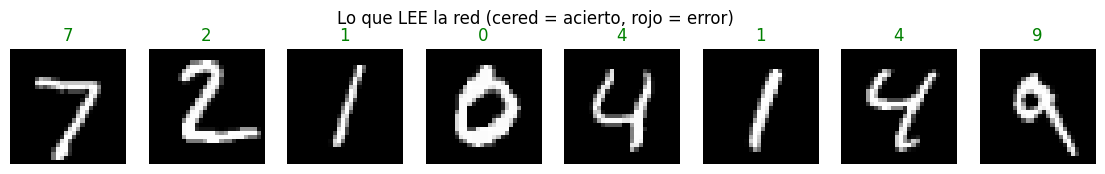

In [11]:
# predict es el método que se encarga de hacer predicciones con el modelo entrenado. Toma un conjunto de datos (X_test) y devuelve las probabilidades de cada clase para cada muestra.
preds = modelo.predict(X_test[:8], verbose=0)#las 8 primeras imagenes del test, para ver que lee la red

fig, ax = plt.subplots(1, 8, figsize=(14, 2))  #crea 8 minigraficos para mostrar las 8 primeras imagenes del test, y lo que lee la red
for k in range(8): #recorre las 8 primeras imagenes del test
    p = int(np.argmax(preds[k])) #argmax devuelve el indice de la clase con mayor probabilidad, es decir, lo que la red "cree" que es cada imagen
    ax[k].imshow(X_test[k], cmap='gray') #muestra la imagen del test
    color = 'green' if p == y_test[k] else 'red' #si la prediccion es correcta (p == y_test[k]) el titulo se muestra en verde, sino en rojo
    ax[k].set_title(str(p), color=color) #titulo del grafico es la prediccion de la red, con el color correspondiente
    ax[k].axis('off')

plt.suptitle('Lo que LEE la red (cered = acierto, rojo = error)')
plt.show()

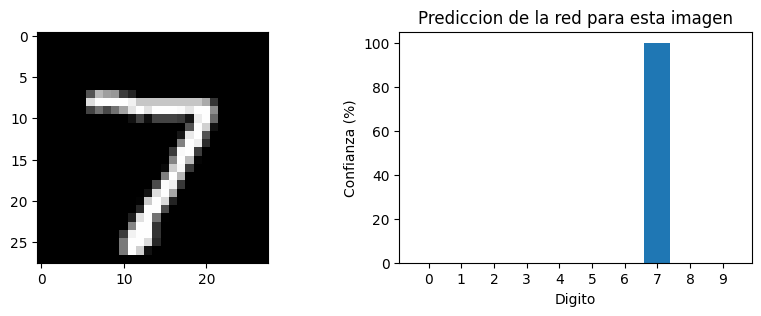

In [13]:

i=0

probs = modelo.predict(X_test[i:i+1], verbose=0)[0] #predice la probabilidad de cada clase para la imagen i del test

fig, ax = plt.subplots(1, 2, figsize=(10, 3)) #crea dos minigraficos para mostrar la imagen del test y las probabilidades de cada clase
ax[0].imshow(X_test[i], cmap='gray') #muestra la imagen del test
ax[1].bar(range(10), probs*100) #muestra un grafico de barras con las probabilidades de cada clase
ax[1].set_xticks(range(10)) #pone los numeros del 0 al 9 en el eje x del grafico de barras
ax[1].set_xlabel('Digito'); ax[1].set_ylabel('Confianza (%)')
ax[1].set_title('Prediccion de la red para esta imagen')
plt.show()

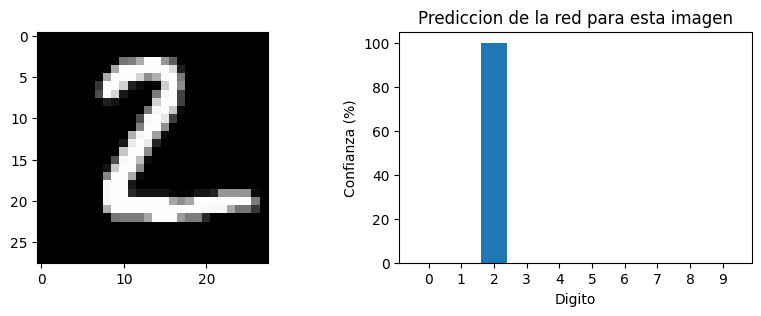

In [14]:
i=1

probs = modelo.predict(X_test[i:i+1], verbose=0)[0] #predice la probabilidad de cada clase para la imagen i del test

fig, ax = plt.subplots(1, 2, figsize=(10, 3)) #crea dos minigraficos para mostrar la imagen del test y las probabilidades de cada clase
ax[0].imshow(X_test[i], cmap='gray') #muestra la imagen del test
ax[1].bar(range(10), probs*100) #muestra un grafico de barras con las probabilidades de cada clase
ax[1].set_xticks(range(10)) #pone los numeros del 0 al 9 en el eje x del grafico de barras
ax[1].set_xlabel('Digito'); ax[1].set_ylabel('Confianza (%)')
ax[1].set_title('Prediccion de la red para esta imagen')
plt.show()

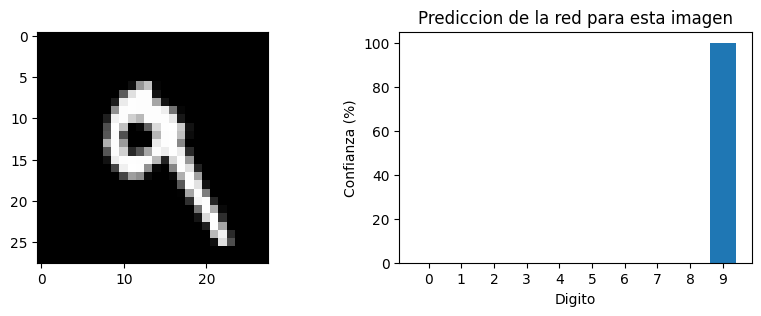

In [15]:
i=7

probs = modelo.predict(X_test[i:i+1], verbose=0)[0] #predice la probabilidad de cada clase para la imagen i del test

fig, ax = plt.subplots(1, 2, figsize=(10, 3)) #crea dos minigraficos para mostrar la imagen del test y las probabilidades de cada clase
ax[0].imshow(X_test[i], cmap='gray') #muestra la imagen del test
ax[1].bar(range(10), probs*100) #muestra un grafico de barras con las probabilidades de cada clase
ax[1].set_xticks(range(10)) #pone los numeros del 0 al 9 en el eje x del grafico de barras
ax[1].set_xlabel('Digito'); ax[1].set_ylabel('Confianza (%)')
ax[1].set_title('Prediccion de la red para esta imagen')
plt.show()

Imagen del test numero 1234 la red dice 8 con una confianza del 93.4 % y la etiqueta real es 8


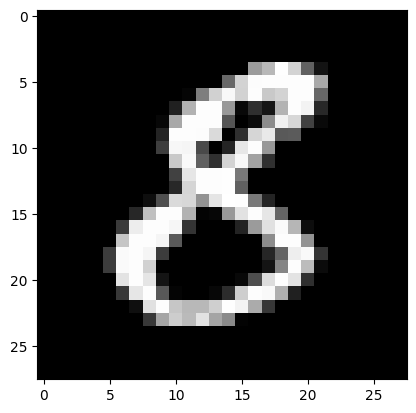

In [16]:
i = 1234

probs = modelo.predict(X_test[i:i+1], verbose=0)[0] #predice la probabilidad de cada clase para la imagen i del test
pred = int(probs.argmax()) #argmax devuelve el indice de la clase con mayor probabilidad, es decir, lo que la red "cree" que es cada imagen

print('Imagen del test numero', i, 'la red dice', pred, 'con una confianza del',
       round(float(probs[pred])*100, 1), '%', 'y la etiqueta real es', y_test[i])

plt.imshow(X_test[i], cmap='gray')
plt.show()
 

In [25]:
# Definimos una FUNCION para no repetir codigo. Recibe 3 parametros con valor por defecto:
#   neuronas -> cuantas neuronas tiene cada capa oculta
#   capas    -> cuantas capas ocultas apilamos
#   epochs   -> cuantas vueltas de entrenamiento
def construir_y_entrenar(neuronas=128, capas=1, epochs=3): # estos valores por defecto se usan si no se especifican al llamar a la funcion
    # Empezamos SIEMPRE igual: la entrada 28x28 y el aplanado a 784. Lo metemos en una lista:
    capas_red = [keras.layers.Input(shape=(28, 28)), keras.layers.Flatten()]

    # Anadimos a la lista tantas capas ocultas como diga 'capas', cada una con 'neuronas' neuronas.
    # range(capas) repite el bucle 'capas' veces; usamos _ porque no necesitamos el contador.
    for _ in range(capas):
        capas_red.append(keras.layers.Dense(neuronas, activation='relu'))

    # La SALIDA es siempre igual: 10 neuronas con softmax (una por digito). La anadimos al final.
    capas_red.append(keras.layers.Dense(10, activation='softmax'))

    red = keras.Sequential(capas_red)                # construimos la red con la lista de capas
    red.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    # verbose=2 -> imprime solo 1 linea por epoch (mas limpio que la barra de progreso por defecto).
    red.fit(X_train, y_train, epochs=epochs, validation_split=0.1, verbose=2)
    acc = red.evaluate(X_test, y_test, verbose=0)[1] # accuracy en test
    print('>> Accuracy en test:', round(acc * 100, 2), '%')
    return red, acc                                  # devolvemos la red entrenada y su accuracy

# Probamos una red mas grande: 2 capas ocultas de 256 neuronas cada una.
# (Recibimos 2 valores porque la funcion devuelve 2; el '_' significa "este no lo uso".)
red_seleccinada, _acc = construir_y_entrenar(neuronas=256, capas=2, epochs=5) # parametros elegidos para que la red sea mas grande y entrene mas, pero sin tardar demasiado. Pueden probar a cambiar estos parametros para ver que pasa.

Epoch 1/5
1688/1688 - 12s - 7ms/step - accuracy: 0.9369 - loss: 0.2110 - val_accuracy: 0.9685 - val_loss: 0.1063
Epoch 2/5
1688/1688 - 9s - 5ms/step - accuracy: 0.9726 - loss: 0.0870 - val_accuracy: 0.9755 - val_loss: 0.0784
Epoch 3/5
1688/1688 - 9s - 5ms/step - accuracy: 0.9807 - loss: 0.0591 - val_accuracy: 0.9787 - val_loss: 0.0732
Epoch 4/5
1688/1688 - 10s - 6ms/step - accuracy: 0.9853 - loss: 0.0454 - val_accuracy: 0.9783 - val_loss: 0.0795
Epoch 5/5
1688/1688 - 10s - 6ms/step - accuracy: 0.9881 - loss: 0.0348 - val_accuracy: 0.9832 - val_loss: 0.0624
>> Accuracy en test: 97.9 %


In [26]:
mi_red, mi_acc = construir_y_entrenar(neuronas=96, capas=2, epochs=3)

Epoch 1/3
1688/1688 - 8s - 5ms/step - accuracy: 0.9254 - loss: 0.2572 - val_accuracy: 0.9682 - val_loss: 0.1111
Epoch 2/3
1688/1688 - 6s - 4ms/step - accuracy: 0.9662 - loss: 0.1102 - val_accuracy: 0.9713 - val_loss: 0.0980
Epoch 3/3
1688/1688 - 6s - 4ms/step - accuracy: 0.9756 - loss: 0.0781 - val_accuracy: 0.9765 - val_loss: 0.0804
>> Accuracy en test: 97.35 %


In [27]:
red_pequena, _ = construir_y_entrenar(neuronas=16, capas=1, epochs=4)

Epoch 1/4
1688/1688 - 7s - 4ms/step - accuracy: 0.8740 - loss: 0.4474 - val_accuracy: 0.9332 - val_loss: 0.2346
Epoch 2/4
1688/1688 - 5s - 3ms/step - accuracy: 0.9229 - loss: 0.2701 - val_accuracy: 0.9397 - val_loss: 0.2059
Epoch 3/4
1688/1688 - 5s - 3ms/step - accuracy: 0.9332 - loss: 0.2340 - val_accuracy: 0.9482 - val_loss: 0.1847
Epoch 4/4
1688/1688 - 5s - 3ms/step - accuracy: 0.9393 - loss: 0.2093 - val_accuracy: 0.9493 - val_loss: 0.1710
>> Accuracy en test: 94.06 %


In [28]:
red_grande, _acc = construir_y_entrenar(neuronas=256, capas=2, epochs=5)

Epoch 1/5
1688/1688 - 15s - 9ms/step - accuracy: 0.9355 - loss: 0.2133 - val_accuracy: 0.9713 - val_loss: 0.1004
Epoch 2/5
1688/1688 - 9s - 5ms/step - accuracy: 0.9724 - loss: 0.0904 - val_accuracy: 0.9787 - val_loss: 0.0723
Epoch 3/5
1688/1688 - 9s - 5ms/step - accuracy: 0.9806 - loss: 0.0608 - val_accuracy: 0.9728 - val_loss: 0.0838
Epoch 4/5
1688/1688 - 9s - 5ms/step - accuracy: 0.9854 - loss: 0.0446 - val_accuracy: 0.9792 - val_loss: 0.0697
Epoch 5/5
1688/1688 - 9s - 5ms/step - accuracy: 0.9877 - loss: 0.0371 - val_accuracy: 0.9752 - val_loss: 0.0843
>> Accuracy en test: 97.44 %


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


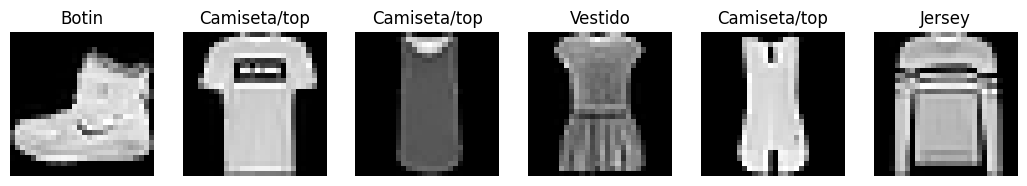

In [23]:
# 🟦 DEMO - Cargamos Fashion-MNIST. Mismo formato que MNIST (28x28 gris), pero son PRENDAS de ropa.
(Xf_train, yf_train), (Xf_test, yf_test) = keras.datasets.fashion_mnist.load_data()

# Aqui las etiquetas 0-9 son TIPOS DE ROPA, no numeros. Esta lista traduce cada numero a su nombre:
#   (la posicion 0 de la lista es el nombre de la etiqueta 0, la 1 el de la etiqueta 1, etc.)
clases = ['Camiseta/top', 'Pantalon', 'Jersey', 'Vestido', 'Abrigo',
          'Sandalia', 'Camisa', 'Zapatilla', 'Bolso', 'Botin']

fig, ax = plt.subplots(1, 6, figsize=(13, 2.5))
for k in range(6):
    ax[k].imshow(Xf_train[k], cmap='gray')
    ax[k].set_title(clases[yf_train[k]])             # clases[etiqueta] -> el NOMBRE en vez del numero
    ax[k].axis('off')
plt.show()

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.8220 - loss: 0.5051 - val_accuracy: 0.8430 - val_loss: 0.4116
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8641 - loss: 0.3772 - val_accuracy: 0.8652 - val_loss: 0.3817
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8761 - loss: 0.3399 - val_accuracy: 0.8647 - val_loss: 0.3605
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8854 - loss: 0.3147 - val_accuracy: 0.8790 - val_loss: 0.3318
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8914 - loss: 0.2962 - val_accuracy: 0.8752 - val_loss: 0.3344
Accuracy en test (ropa): 87.4 %


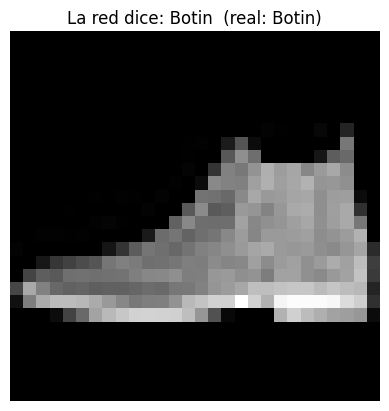

In [29]:
# -- SOLUCION Reto --
Xf_train = Xf_train / 255.0                            # 1) normalizar (mismo motivo que en MNIST: numeros 0-1)
Xf_test  = Xf_test  / 255.0

red_ropa = keras.Sequential([                          # 2) construir (MISMA estructura que el Bloque 1)
    keras.layers.Input(shape=(28, 28)),
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(10,  activation='softmax'),
])
red_ropa.compile(optimizer='adam',                     # 3) compilar (identico a MNIST)
                 loss='sparse_categorical_crossentropy',
                 metrics=['accuracy'])
red_ropa.fit(Xf_train, yf_train, epochs=5, validation_split=0.1)   # 4) entrenar
acc = red_ropa.evaluate(Xf_test, yf_test, verbose=0)[1]           # 5) evaluar (accuracy en test)
print('Accuracy en test (ropa):', round(acc * 100, 1), '%')

# Predecimos una prenda y la ensenamos con su NOMBRE (traduciendo la etiqueta con la lista 'clases'):
i = 0
pred = int(red_ropa.predict(Xf_test[i:i+1], verbose=0).argmax())   # digito/clase predicha
plt.imshow(Xf_test[i], cmap='gray'); plt.axis('off')
plt.title('La red dice: ' + clases[pred] + '  (real: ' + clases[yf_test[i]] + ')')
plt.show()

Creating new Ultralytics Settings v0.0.6 file  
View Ultralytics Settings with 'yolo settings' or at 'C:\Users\Carlos\AppData\Roaming\Ultralytics\settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


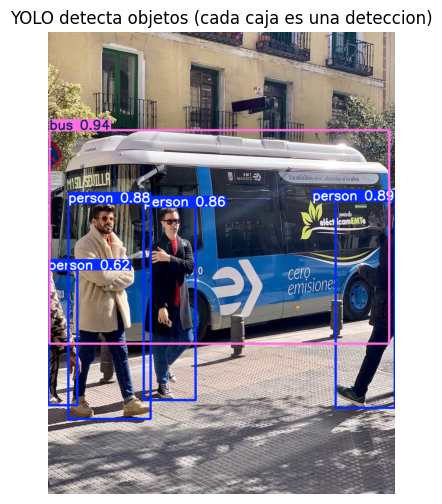

Objetos detectados:
 - bus
 - person
 - person
 - person
 - person


In [30]:
# 🟦 DEMO - YOLO sobre una foto. Solo lo USAMOS (ya viene entrenado por otros); no entrenamos nada.
from ultralytics import YOLO            # YOLO = modelo de deteccion de objetos, listo para usar
import urllib.request, os

if not os.path.exists('foto.jpg'):      # si no tenemos la foto de ejemplo, la descargamos
    urllib.request.urlretrieve('https://ultralytics.com/images/bus.jpg', 'foto.jpg')

modelo_yolo = YOLO('yolo11n.pt')        # carga el modelo. 'n' = nano (el mas ligero). Se baja solo la 1a vez.
resultado = modelo_yolo('foto.jpg', verbose=False)   # le pasamos la foto. verbose=False -> sin detalles tecnicos

# resultado[0] = el analisis de nuestra (unica) imagen.  .plot() = la imagen con las cajas YA dibujadas.
anotada = resultado[0].plot()           # devuelve un array de pixeles en orden BGR (azul-verde-rojo)
plt.figure(figsize=(8, 6))
plt.imshow(anotada[:, :, ::-1])         # [:, :, ::-1] invierte el ultimo eje: pasa de BGR a RGB para verla bien
plt.axis('off'); plt.title('YOLO detecta objetos (cada caja es una deteccion)')
plt.show()

print('Objetos detectados:')
for c in resultado[0].boxes.cls:        # boxes.cls = lista con la clase (un numero) de cada caja detectada
    print(' -', modelo_yolo.names[int(c)])   # .names traduce ese numero a su nombre ('person', 'bus'...)